In [1]:
# в Colab git уже подтянет нужный коммит ветки
!pip install -q --no-deps "git+https://github.com/filkinc/diploma_centpy_parallelization_py.git@feature/some-fix"
!pip install -q scienceplots          # доп. зависимости, которых нет в Colab

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import jax_centpy
from jax_centpy import Solver1d, Pars1d, make_burgers_1d
print("Версия:", jax_centpy.__version__ if hasattr(jax_centpy, "__version__") else "0.1.0")

Версия: 0.1.0


In [8]:
import os
import time
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np
from google.colab import files
from typing import Callable, NamedTuple

from jax_centpy import Pars2d, Equation2d, Pars1d, Equation1d, Solver1d, make_euler_riemann_2d, make_euler_isentropic_vortex_2d, make_burgers_1d

In [9]:
def make_modified_sod(gamma=1.4, alpha: float = 0.1) -> Equation1d:
    def compute_pressure(q):
        rho = q[..., 0]
        u = q[..., 1] / rho
        E = q[..., 2]
        return (gamma - 1.0) * (E - 0.5 * rho * u**2)

    def flux(q):
        rho = q[..., 0]
        rhou = q[..., 1]
        E = q[..., 2]
        rhosafe = jnp.maximum(rho, 1e-10)
        u = rhou / rhosafe
        p = compute_pressure(q)
        return jnp.stack([rhou, rhou * u + p, u * (E + p)], axis=-1)

    def spectral_radius(q):
        rho = q[..., 0]
        rhou = q[..., 1]
        rhosafe = jnp.maximum(rho, 1e-10)
        u = rhou / rhosafe
        p = jnp.maximum(compute_pressure(q), 1e-10)
        c = jnp.sqrt(gamma * p / rhosafe)
        a = jnp.abs(u) + c
        return a[..., None]

    def initial_data(x):
        # Невозмущенный газ
        rho_0, p_0 = 1.0, 1.0

        # Состояние за ударной волной (по Ренкину-Гюгонио для M=2)
        rho_R = 2.66666666667
        p_R = 4.5
        u_R = -1.47901994677

        # Границы областей
        x_0 = 0.3
        x_1 = 0.5
        x_sw = 0.8

        # Кусочно-постоянное распределение плотности
        rho = jnp.where(x < x_0, rho_0,
                jnp.where(x <= x_1, alpha * rho_0,
                jnp.where(x < x_sw, rho_0, rho_R)))

        # Распределение скорости (движется только газ за фронтом УВ)
        u = jnp.where(x < x_sw, 0.0, u_R)

        # Распределение давления
        p = jnp.where(x < x_0, p_0,
                jnp.where(x <= x_1, p_0,
                jnp.where(x < x_sw, p_0, p_R)))

        E = p / (gamma - 1.0) + 0.5 * rho * u**2
        return jnp.stack([rho, rho * u, E], axis=-1)

    def mixed_bc(u, n_ghost):
        # Левая граница: условия Неймана (нулевой градиент / свободный выход волны)
        # Повторяем значения из первой внутренней ячейки (index 0) n_ghost раз.
        left_ghost = jnp.repeat(u[:1], n_ghost, axis=0)

        # Правая граница: непротекание (твердая стенка)
        # Зеркальное отражение плотности и энергии, но смена знака для импульса (u[:, 1]).
        right_ghost = u[-n_ghost:][::-1]
        right_ghost = right_ghost.at[:, 1].set(-right_ghost[:, 1])

        # Склеиваем фиктивные ячейки с основной расчетной областью
        return jnp.concatenate([left_ghost, u, right_ghost], axis=0)

    return Equation1d(
        flux=flux,
        spectral_radius=spectral_radius,
        initial_data=initial_data,
        boundary_handler=mixed_bc,  # Подключаем наши новые смешанные условия
        name="Modified Sod (Left: Neumann, Right: Wall)"
    )

In [11]:
# Инициализация уравнения и параметров
eqn = make_modified_sod()
pars = Pars1d(x_init=0.0, x_final=1.0, t_final=0.4, dt_out=0.005, J=400, cfl=0.45)
solver = Solver1d(pars, eqn, scheme_name='sd2', limiter_name="minmod")

print("Запуск расчёта...")
t0 = time.time()
sol = solver.solve()
t1 = time.time()
print(f"\n[GPU JAX] Чистое время выполнения: {t1 - t0:.4f} секунд")
print("Расчёт успешно завершён!")

# Извлечение результатов
x_num = np.array(sol["x"])
t_num = np.array(sol["t"])
q_num = np.array(sol["u_n"])

# Декодирование консервативных переменных в примитивные
rho_num = q_num[..., 0]
u_num = q_num[..., 1] / q_num[..., 0]
p_num = 0.4 * (q_num[..., 2] - 0.5 * rho_num * u_num**2)

Запуск расчёта...

[GPU JAX] Чистое время выполнения: 0.7772 секунд
Расчёт успешно завершён!


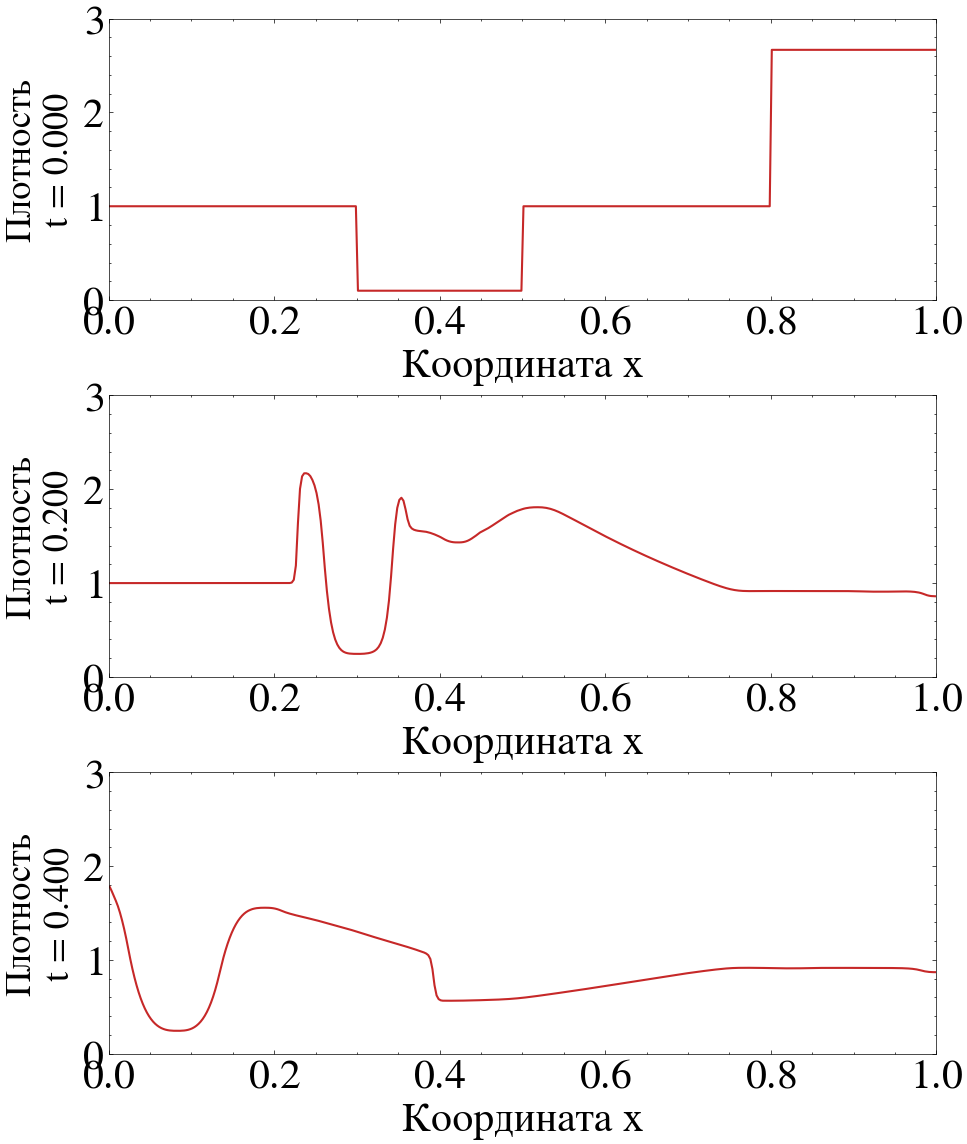

Сохранено: rho_evolution.png


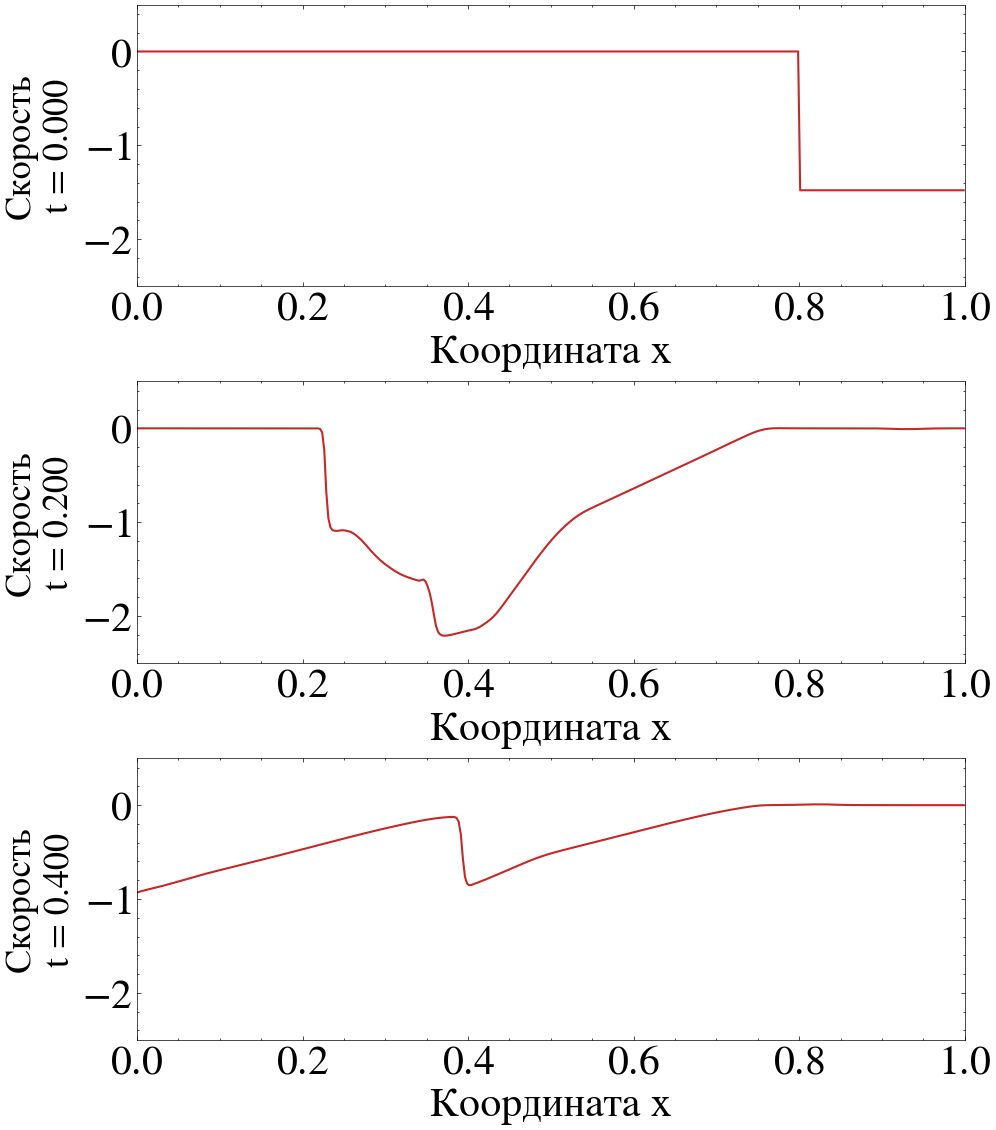

Сохранено: u_evolution.png


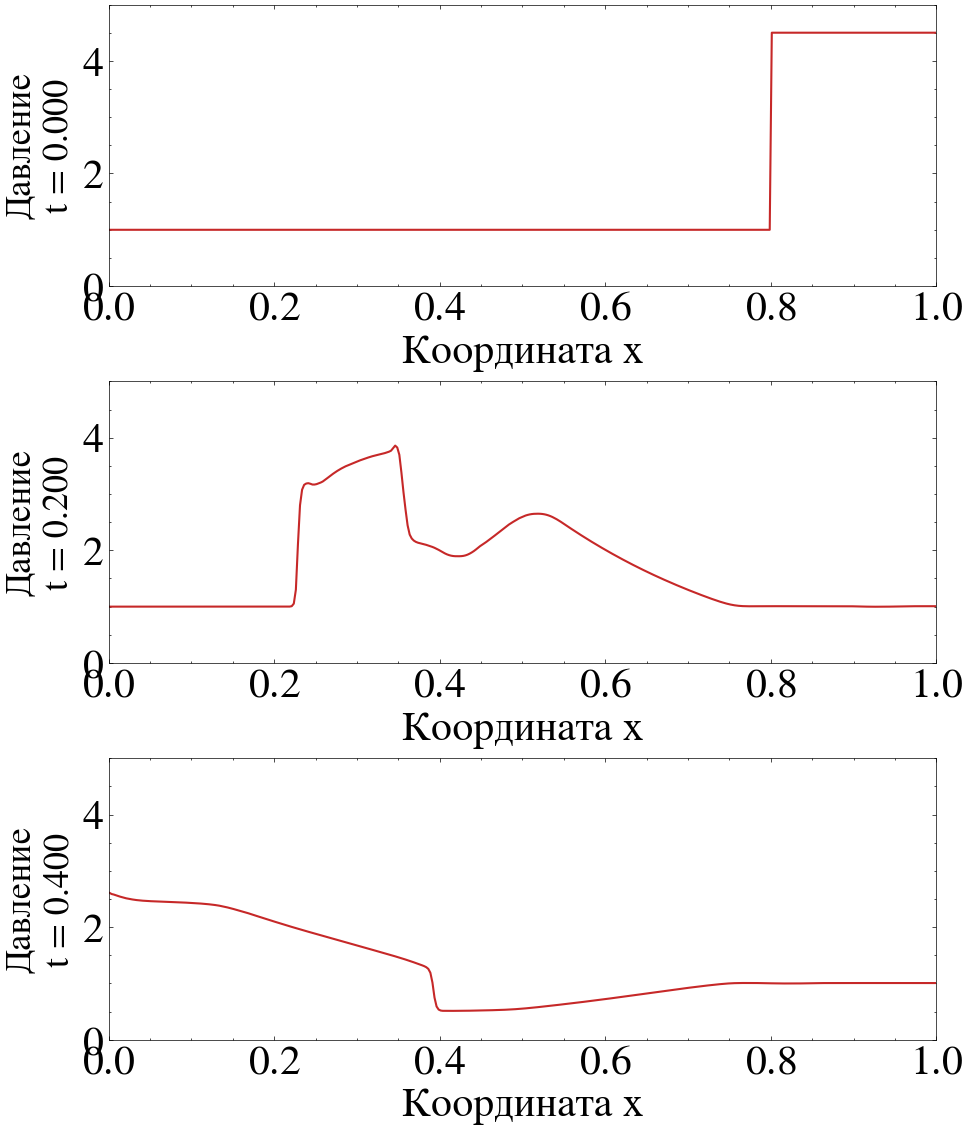

Сохранено: p_evolution.png


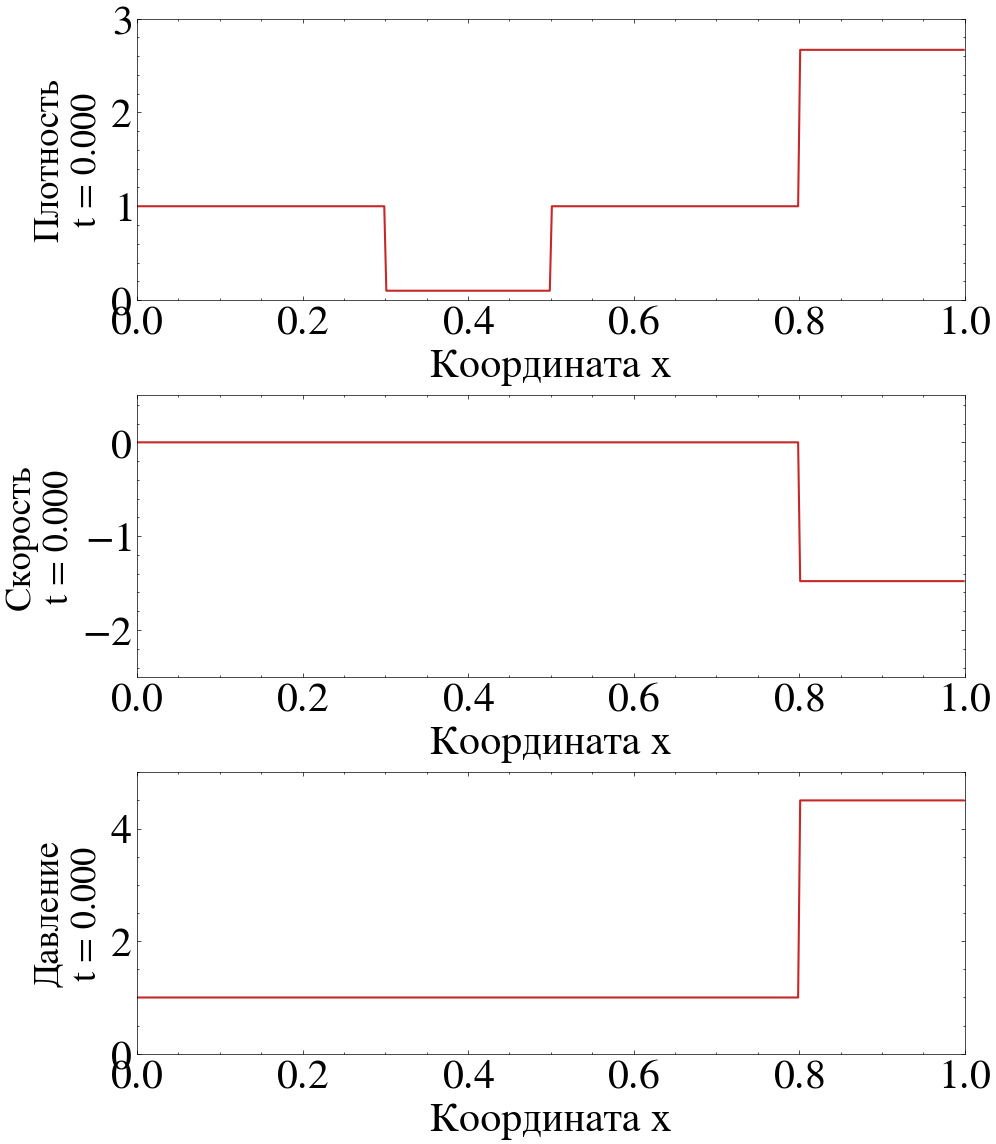

Сохранено: combined_final_state.png


In [12]:
import scienceplots
import matplotlib.pyplot as plt

plt.style.use(['science', 'no-latex'])

# Индексы трёх моментов времени
idx_start = 0
idx_mid   = len(t_num) // 2
idx_end   = len(t_num) - 1

time_indices = [idx_start, idx_mid, idx_end]

# Настройки для каждой переменной
variables = [
    {'data': rho_num, 'ylabel': 'Плотность', 'ylim': (0.0, 3.0),  'color': '#C62828'},
    {'data': u_num,   'ylabel': 'Скорость',   'ylim': (-2.5, 0.5), 'color': '#C62828'},
    {'data': p_num,   'ylabel': 'Давление',   'ylim': (0.0, 5.0),  'color': '#C62828'},
]
filenames = ['rho_evolution.png', 'u_evolution.png', 'p_evolution.png']

# === 1. Графики эволюции каждой переменной во времени ===
for var, fname in zip(variables, filenames):
    fig, axes = plt.subplots(3, 1, figsize=(10, 12))
    fig.tight_layout(pad=5.0)

    for row, idx in enumerate(time_indices):
        ax = axes[row]
        ax.plot(x_num, var['data'][idx], color=var['color'], linewidth=1.5)
        ax.set_xlim(0, 1)
        ax.set_ylim(*var['ylim'])
        ax.set_ylabel(f"{var['ylabel']}\nt = {t_num[idx]:.3f}", fontsize=26)

        # Теперь ось x подписывается и отображается на каждом графике
        ax.set_xlabel('Координата x', fontsize=30)
        ax.tick_params(axis='both', labelsize=30)

    fig.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Сохранено: {fname}')


# === 2. Сводный график всех переменных для конечного момента времени ===
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
fig.tight_layout(pad=5.0)
fname_combined = 'combined_final_state.png'

for i, var in enumerate(variables):
    ax = axes[i]
    # Используем данные только для начального момента времени (idx_start)
    ax.plot(x_num, var['data'][idx_start], color=var['color'], linewidth=1.5)
    ax.set_xlim(0, 1)
    ax.set_ylim(*var['ylim'])
    ax.set_ylabel(f"{var['ylabel']}\nt = {t_num[idx_start]:.3f}", fontsize=26)

    # Подписи оси x для каждого подграфика
    ax.set_xlabel('Координата x', fontsize=30)
    ax.tick_params(axis='both', labelsize=30)

fig.savefig(fname_combined, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Сохранено: {fname_combined}')